03:
加入localization擾動 畫trajectory
跟baseline TTC比較

In [5]:
import pandas as pd

df_ttc = pd.read_csv("/content/1_baseline_ttc.csv")

df_ttc.head()

,frame,track_id,class_id,confidence,x1,y1,x2,y2,center_x,center_y,...,height_deviation,height_relative_deviation,scale,scale_smooth,scale_rate,slope_5,slope_15,slope_30,ttc,actual_time_to_impact
0,0,2,2,0.857051,412.799744,398.197266,629.303406,573.998047,521.051575,486.097656,...,NaN,NaN,195.093600,NaN,NaN,NaN,NaN,NaN,NaN,19.230000
1,1,2,2,0.842265,413.395966,398.231476,628.552734,572.919189,520.974350,485.575333,...,NaN,NaN,193.869141,NaN,NaN,NaN,NaN,NaN,NaN,19.196667
2,2,2,2,0.848210,411.766449,398.202423,630.319336,575.702637,521.042892,486.952530,...,NaN,NaN,196.959854,196.959854,NaN,22.746589,NaN,NaN,NaN,19.163333
3,3,2,2,0.850965,411.815491,398.216736,630.416443,575.776917,521.115967,486.996826,...,NaN,NaN,197.014783,196.963495,0.109233,19.622194,NaN,NaN,NaN,19.130000
4,4,2,2,0.844924,411.758881,398.215088,630.668213,576.060303,521.213547,487.137695,...,NaN,NaN,197.311878,196.963495,0.000000,-12.026570,NaN,NaN,NaN,19.096667


In [24]:
#03所需的02 func
# ==========================================
# Notebook 02 — Localization Error Experiment
# Common Setup
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2


# ---------- 1. Load baseline ----------
df_ttc = pd.read_csv("/content/1_baseline_ttc.csv")


# ---------- 2. Rolling slope ----------
def rolling_slope(df, window):

    slopes = []
    half = window // 2

    for i in range(len(df)):

        if i < half or i >= len(df) - half:
            slopes.append(np.nan)
            continue

        local = df.iloc[i-half : i+half+1]

        x = local["time"].values
        y = local["scale"].values

        a, b = np.polyfit(x, y, 1)

        slopes.append(a)

    return slopes


# ---------- 3. Shrink bbox to target IoU ----------
def shrink_bbox_to_iou(row, target_iou):

    x1, y1, x2, y2 = row["x1"], row["y1"], row["x2"], row["y2"]

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2

    width = x2 - x1
    height = y2 - y1

    # 同中心縮小時：
    # IoU = new_area / original_area
    # 所以 width、height 各乘 sqrt(IoU)
    scale_factor = np.sqrt(target_iou)

    new_width = width * scale_factor
    new_height = height * scale_factor

    new_x1 = cx - new_width / 2
    new_y1 = cy - new_height / 2
    new_x2 = cx + new_width / 2
    new_y2 = cy + new_height / 2

    return new_x1, new_y1, new_x2, new_y2

#duration = 3 / 5 / 10 的 sanity check。->決定duration
def run_duration_test(duration, target_iou=0.7):

    results = []

    for start_frame in range(493, 533 - duration + 2):

        end_frame = start_frame + duration - 1
        df_temp = df_ttc.copy()

        # 加入 under-boxing
        for idx in df_temp[
            df_temp["frame"].between(start_frame, end_frame)
        ].index:

            row = df_temp.loc[idx]
            new_box = shrink_bbox_to_iou(row, target_iou)

            df_temp.loc[idx, ["x1","y1","x2","y2"]] = new_box

        # 重算 scale
        df_temp["bbox_width"] = df_temp["x2"] - df_temp["x1"]
        df_temp["bbox_height"] = df_temp["y2"] - df_temp["y1"]

        df_temp["scale"] = np.sqrt(
            df_temp["bbox_width"] * df_temp["bbox_height"]
        )

        # 重算 slope + TTC
        df_temp["slope_15"] = rolling_slope(df_temp, 15)

        df_temp["ttc_perturbed"] = np.where(
            df_temp["slope_15"] > 0,
            df_temp["scale"] / df_temp["slope_15"],
            np.nan
        )

        # slope_15 前後各使用 7 frames
        affected_start = max(493, start_frame - 7)
        affected_end   = min(533, end_frame + 7)

        # 比較 baseline
        valid = (
            df_ttc["frame"].between(affected_start, affected_end)
            & df_ttc["ttc"].notna()
        )

        temp = pd.DataFrame({
            "baseline": df_ttc.loc[valid, "ttc"],
            "perturbed": df_temp.loc[valid, "ttc_perturbed"]
        })

        # perturbed TTC 消失的數量
        failures = temp["perturbed"].isna().sum()

        # 正常可以比較的 TTC
        comparable = temp.dropna()

        abs_delta = (
            comparable["perturbed"] - comparable["baseline"]
        ).abs()

        results.append({
            "start_frame": start_frame,
            "end_frame": end_frame,
            "median_abs_delta": abs_delta.median(),
            "failures": failures
        })

    return pd.DataFrame(results)


print("Setup complete")
print("df_ttc shape:", df_ttc.shape)


Setup complete
df_ttc shape: (541, 25)


In [6]:
print(df_ttc.columns.tolist())

['frame', 'track_id', 'class_id', 'confidence', 'x1', 'y1', 'x2', 'y2', 'center_x', 'center_y', 'time', 'time_to_impact', 'bbox_width', 'bbox_height', 'height_median', 'height_deviation', 'height_relative_deviation', 'scale', 'scale_smooth', 'scale_rate', 'slope_5', 'slope_15', 'slope_30', 'ttc', 'actual_time_to_impact']


In [7]:
#確認影片裡，baseline TTC 真正有意義dot{s}>0的區間有多長？
positive_ttc = df_ttc[
    (df_ttc["slope_15"] > 0) &
    (df_ttc["ttc"].notna())
]

print("first frame:", positive_ttc["frame"].min())
print("last frame:", positive_ttc["frame"].max())

print("first time:", positive_ttc["time"].min())
print("last time:", positive_ttc["time"].max())

print(
    "duration:",
    positive_ttc["time"].max() - positive_ttc["time"].min(),
    "seconds"
)

print("number of frames:", len(positive_ttc))

first frame: 7
last frame: 533
first time: 0.2333333333333333
last time: 17.766666666666666
duration: 17.53333333333333 seconds
number of frames: 221


In [8]:
#真正需要找的是：
#事故前最後一段「連續的 positive TTC」從哪一 frame 開始，到哪一 frame 結束？

mask = (df_ttc["slope_15"] > 0) & (df_ttc["ttc"].notna())

# 找出每一段連續 positive TTC 屬於哪一組
groups = (mask != mask.shift()).cumsum()

positive_segments = (
    df_ttc[mask]
    .groupby(groups[mask])
    .agg(
        start_frame=("frame", "min"),
        end_frame=("frame", "max"),
        start_time=("time", "min"),
        end_time=("time", "max"),
        n_frames=("frame", "count")
    )
)

positive_segments["duration"] = (
    positive_segments["end_time"]
    - positive_segments["start_time"]
)

print(positive_segments.tail(10))

    start_frame  end_frame  start_time   end_time  n_frames  duration
14          157        166    5.233333   5.533333        10  0.300000
16          195        201    6.500000   6.700000         7  0.200000
18          216        225    7.200000   7.500000        10  0.300000
20          249        261    8.300000   8.700000        13  0.400000
22          301        304   10.033333  10.133333         4  0.100000
24          330        345   11.000000  11.500000        16  0.500000
26          355        377   11.833333  12.566667        23  0.733333
28          393        397   13.100000  13.233333         5  0.133333
30          414        425   13.800000  14.166667        12  0.366667
32          493        533   16.433333  17.766667        41  1.333333


In [ ]:
#挑選duration大小(邏輯見google docs.原始notebook)

In [9]:
#把 bbox 縮小到指定 IoU
import numpy as np

#Under-boxing
def shrink_bbox_to_iou(row, target_iou):

    scale = np.sqrt(target_iou)

    cx = (row["x1"] + row["x2"]) / 2
    cy = (row["y1"] + row["y2"]) / 2

    w = (row["x2"] - row["x1"]) * scale
    h = (row["y2"] - row["y1"]) * scale

    return (
        cx - w/2,
        cy - h/2,
        cx + w/2,
        cy + h/2
    )

In [10]:
row = df_ttc[df_ttc["frame"] == 500].iloc[0]

original = [row["x1"], row["y1"], row["x2"], row["y2"]]
perturbed = shrink_bbox_to_iou(row, 0.7)

print("original:", original)
print("perturbed:", perturbed)

original: [np.float64(430.79107666015625), np.float64(404.3970642089844), np.float64(597.7628173828125), np.float64(542.1812744140625)]
perturbed: (np.float64(444.4276565097552), np.float64(415.6498988284448), np.float64(584.1262375332135), np.float64(530.9284397946021))


In [11]:
#確認是否成功縮放 使IoU為0.7
def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2-x1) * max(0, y2-y1)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    return intersection / (area1 + area2 - intersection)

print("IoU:", calculate_iou(original, perturbed))

IoU: 0.6999999999999997


In [12]:
"""
pilot exp
493–495 → bbox 縮小到 IoU = 0.7
然後確認：
1. 只有 493–495 被改動。
2. 三個 bbox 的 IoU 都是 0.7。
3. 其他 frame 完全沒變。
這三點確認後，再讓程式自動滑動 39 次。
"""

df_test = df_ttc.copy()

# 只擾動 frame 493–495
for idx in df_test[df_test["frame"].between(493, 495)].index:

    row = df_test.loc[idx]
    new_box = shrink_bbox_to_iou(row, 0.7)

    df_test.loc[idx, ["x1", "y1", "x2", "y2"]] = new_box

for frame in [493, 494, 495]:

    original = df_ttc[df_ttc["frame"] == frame].iloc[0]
    changed = df_test[df_test["frame"] == frame].iloc[0]

    original_box = [
        original["x1"], original["y1"],
        original["x2"], original["y2"]
    ]

    changed_box = [
        changed["x1"], changed["y1"],
        changed["x2"], changed["y2"]
    ]

    print(frame, calculate_iou(original_box, changed_box))

493 0.7000000000000005
494 0.6999999999999997
495 0.7


In [14]:
VIDEO_PATH = "/content/1.mp4"

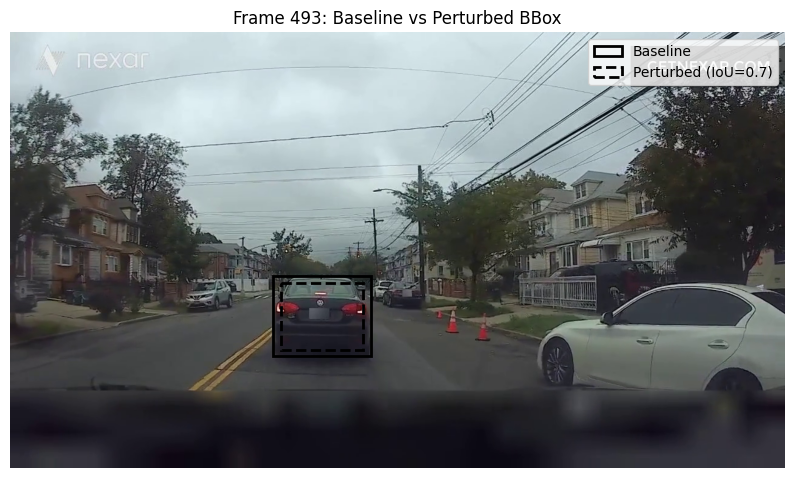

In [15]:
#看擾動後跟原本的bbox
import cv2
import matplotlib.pyplot as plt

frame_to_show = 493

# 讀影片的指定 frame
cap = cv2.VideoCapture("/content/1.mp4")
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_to_show)
ret, img = cap.read()
cap.release()

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# baseline bbox
original = df_ttc[df_ttc["frame"] == frame_to_show].iloc[0]

# perturbed bbox
changed = df_test[df_test["frame"] == frame_to_show].iloc[0]

# 畫 baseline
plt.figure(figsize=(10, 6))
plt.imshow(img)

plt.gca().add_patch(
    plt.Rectangle(
        (original.x1, original.y1),
        original.x2-original.x1,
        original.y2-original.y1,
        fill=False,
        linewidth=2,
        label="Baseline"
    )
)

# 畫 perturbed
plt.gca().add_patch(
    plt.Rectangle(
        (changed.x1, changed.y1),
        changed.x2-changed.x1,
        changed.y2-changed.y1,
        fill=False,
        linewidth=2,
        linestyle="--",
        label="Perturbed (IoU=0.7)"
    )
)

plt.legend()
plt.title("Frame 493: Baseline vs Perturbed BBox")
plt.axis("off")
plt.show()

In [17]:
import numpy as np
import pandas as pd
def rolling_slope(df, window):

    slopes = []
    half = window // 2

    for i in range(len(df)):

        # window 超出資料範圍
        if i < half or i >= len(df) - half:
            slopes.append(np.nan)
            continue

        # 取目前 frame 前後的資料
        local = df.iloc[i-half : i+half+1]

        x = local["time"].values
        y = local["scale"].values

        # 找最符合這些點的直線 y = ax + b
        a, b = np.polyfit(x, y, 1)

        # a = ds/dt
        slopes.append(a)

    return slopes

In [18]:
#先重新算 bbox size 和 scale
df_test["bbox_width"] = df_test["x2"] - df_test["x1"]
df_test["bbox_height"] = df_test["y2"] - df_test["y1"]

df_test["scale"] = np.sqrt(
    df_test["bbox_width"] * df_test["bbox_height"]
)

#再用同一個 15-frame rolling slope
df_test["slope_15"] = rolling_slope(df_test, 15)

#最後算 perturbed TTC
df_test["ttc"] = np.where(
    df_test["slope_15"] > 0,
    df_test["scale"] / df_test["slope_15"],
    np.nan
)

#然後比較 baseline 和 perturbed：
comparison = df_ttc[["frame", "time", "ttc"]].copy()

comparison["ttc_perturbed"] = df_test["ttc"]
comparison["delta_ttc"] = (
    comparison["ttc_perturbed"] - comparison["ttc"]
)

print(
    comparison[
        comparison["frame"].between(485, 503) #slope_15 使用前後的 frames，所以擾動可能影響附近的 TTC。
    ].to_string(index=False)
)

 frame      time       ttc  ttc_perturbed  delta_ttc
   485 16.166667       NaN            NaN        NaN
   486 16.200000       NaN            NaN        NaN
   487 16.233333       NaN            NaN        NaN
   488 16.266667       NaN            NaN        NaN
   489 16.300000       NaN            NaN        NaN
   490 16.333333       NaN            NaN        NaN
   491 16.366667       NaN            NaN        NaN
   492 16.400000       NaN            NaN        NaN
   493 16.433333 30.533311            NaN        NaN
   494 16.466667 15.059588      12.654443  -2.405145
   495 16.500000 10.554088       5.707034  -4.847055
   496 16.533333  9.205919       4.713945  -4.491974
   497 16.566667  8.744474       3.700805  -5.043669
   498 16.600000  9.296085       3.165342  -6.130743
   499 16.633333 10.971501       2.862891  -8.108610
   500 16.666667 17.244088       2.735859 -14.508230
   501 16.700000 20.161619       3.669718 -16.491901
   502 16.733333 18.581279       5.748916 -12.

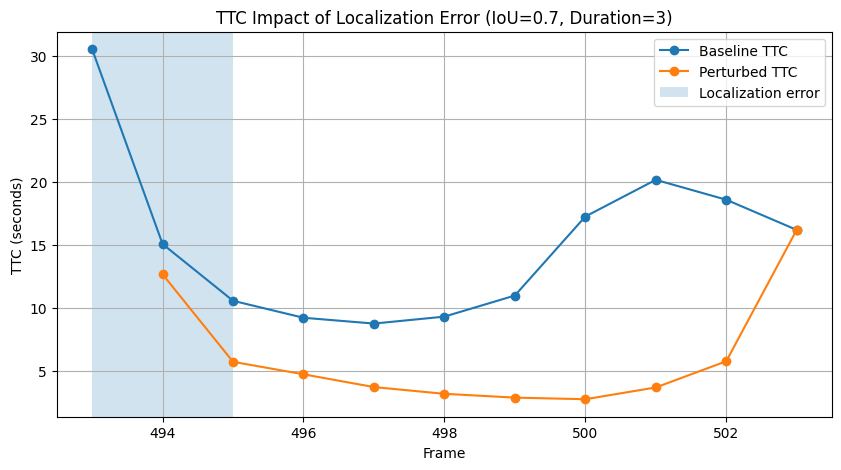

In [19]:
#493–495 是真正 bbox 被改動的區域。
#496–502 bbox 已恢復正常
#確認TTC 是否仍然偏離 baseline。

plot_df = comparison[
    comparison["frame"].between(493, 503)
]

plt.figure(figsize=(10, 5))

plt.plot(
    plot_df["frame"],
    plot_df["ttc"],
    marker="o",
    label="Baseline TTC"
)

plt.plot(
    plot_df["frame"],
    plot_df["ttc_perturbed"],
    marker="o",
    label="Perturbed TTC"
)

# 標出真正被擾動的 493–495
plt.axvspan(
    493, 495,
    alpha=0.2,
    label="Localization error"
)

plt.xlabel("Frame")
plt.ylabel("TTC (seconds)")
plt.title("TTC Impact of Localization Error (IoU=0.7, Duration=3)")
plt.legend()
plt.grid(True)
plt.show()

"""
只改 493–495
->但橘線到 502 都還跟藍線不同

原因:
算dot(s)時用了 15-frame window
->493–495的bbox error會影響附近 frame的slope，進而影響後面的 TTC
->短暫3-frame 的 bbox localization error，確實可以透過 TTC estimation pipeline 傳播，使後續 TTC estimation 明顯偏離 baseline。

In [20]:
#把duration = 3、IoU = 0.7、縮小 bbox 的 error window
#跑遍 frame 493–533 的所有位置

results = []

duration = 3
target_iou = 0.7

for start_frame in range(493, 533 - duration + 2):

    end_frame = start_frame + duration - 1

    # 每次都從乾淨的 baseline 重新開始
    df_temp = df_ttc.copy()

    # 1. 擾動這一次的 n frames
    for idx in df_temp[
        df_temp["frame"].between(start_frame, end_frame)
    ].index:

        row = df_temp.loc[idx]
        new_box = shrink_bbox_to_iou(row, target_iou)

        df_temp.loc[idx, ["x1", "y1", "x2", "y2"]] = new_box

    # 2. 重新計算 scale
    df_temp["bbox_width"] = df_temp["x2"] - df_temp["x1"]
    df_temp["bbox_height"] = df_temp["y2"] - df_temp["y1"]

    df_temp["scale"] = np.sqrt(
        df_temp["bbox_width"] * df_temp["bbox_height"]
    )

    # 3. 重新計算 slope
    df_temp["slope_15"] = rolling_slope(df_temp, 15)

    # 4. 重新計算 TTC
    df_temp["ttc_perturbed"] = np.where(
        df_temp["slope_15"] > 0,
        df_temp["scale"] / df_temp["slope_15"],
        np.nan
    )

    # 5. 跟 baseline 比
    delta = df_temp["ttc_perturbed"] - df_ttc["ttc"]

    affected = delta[
        df_ttc["frame"].between(493, 533)
    ].dropna()

    results.append({
        "start_frame": start_frame,
        "end_frame": end_frame,
        "mean_abs_delta_ttc": affected.abs().mean(),
        "max_abs_delta_ttc": affected.abs().max()
    })

#轉成表格
results_3 = pd.DataFrame(results)

print(results_3)
print(results_3.shape)

    start_frame  end_frame  mean_abs_delta_ttc  max_abs_delta_ttc
0           493        495            1.871492          16.491901
1           494        496            3.177216          46.917314
2           495        497            2.377592          16.914220
3           496        498            2.375501          16.260746
4           497        499            9.333367         266.052165
5           498        500            5.316521         110.508733
6           499        501           34.862151        1172.593900
7           500        502            5.858188         139.543286
8           501        503            1.459278           8.856281
9           502        504           18.581125         593.196113
10          503        505            3.023050          71.385690
11          504        506            1.341204          19.554224
12          505        507            0.939858          10.001063
13          506        508            0.758443           6.678158
14        

出現極值
ex:delta TTC approx = 1173 s

通常代表perturbation讓某些frame的dot s趨近於0
所以TTC會直接爆到非常大

->我故意讓有問題的frame的bbox變小到 IoU = 0.7
看這幾個frames的localization error會透過slope_15傳到哪些 frames&哪一幀的 TTC被影響最大？


In [21]:
# 重跑 523–525 後
# 重新建立 523–525 perturbation
df_check = df_ttc.copy()

for idx in df_check[df_check["frame"].between(523, 525)].index:
    row = df_check.loc[idx]
    new_box = shrink_bbox_to_iou(row, 0.7)
    df_check.loc[idx, ["x1", "y1", "x2", "y2"]] = new_box

# 重新算 scale
df_check["bbox_width"] = df_check["x2"] - df_check["x1"]
df_check["bbox_height"] = df_check["y2"] - df_check["y1"]
df_check["scale"] = np.sqrt(
    df_check["bbox_width"] * df_check["bbox_height"]
)

# 重新算 slope + TTC
df_check["slope_15"] = rolling_slope(df_check, 15)

df_check["ttc_perturbed"] = np.where(
    df_check["slope_15"] > 0,
    df_check["scale"] / df_check["slope_15"],
    np.nan
)

# 找 TTC 差異最大的 frames
check = pd.DataFrame({
    "frame": df_ttc["frame"],
    "baseline_ttc": df_ttc["ttc"],
    "perturbed_ttc": df_check["ttc_perturbed"],
    "baseline_slope": df_ttc["slope_15"],
    "perturbed_slope": df_check["slope_15"]
})

check["abs_delta"] = abs(
    check["perturbed_ttc"] - check["baseline_ttc"]
)

print(
    check[
        check["frame"].between(516, 533)
    ].sort_values("abs_delta", ascending=False)
)

     frame  baseline_ttc  perturbed_ttc  baseline_slope  perturbed_slope  \
520    520      4.620505   47879.610491       36.287020         0.003502   
521    521      4.429314      15.372645       38.247790        11.020320   
516    516      4.451942      10.398966       36.605130        15.671166   
522    522      4.271004       7.832767       39.961248        21.789826   
530    530      2.820295       1.539462       65.236675       119.513637   
529    529      2.869288       1.673741       63.308324       108.529238   
528    528      3.022727       1.881936       59.660319        95.825185   
531    531      2.857329       1.781018       65.210957       104.619437   
525    525      3.565976       2.519661       48.870910        57.867632   
527    527      3.087279       2.095687       57.293309        84.402127   
526    526      3.278546       2.448437       53.247331        71.300101   
532    532      2.937870       2.207026       64.471044        85.820289   
524    524  

In [25]:
results_3  = run_duration_test(3)
results_5  = run_duration_test(5)
results_10 = run_duration_test(10)

print("3 frames")
print(results_3[["median_abs_delta","failures"]].median())

print("\n5 frames")
print(results_5[["median_abs_delta","failures"]].median())

print("\n10 frames")
print(results_10[["median_abs_delta","failures"]].median())

3 frames
median_abs_delta    2.010692
failures            3.000000
dtype: float64

5 frames
median_abs_delta    2.337566
failures            6.000000
dtype: float64

10 frames
median_abs_delta     2.715217
failures            10.500000
dtype: float64


三種duration測試結論:
都會造成明顯 TTC deviation / failure → 所以「localization error 會傳播到 TTC」不是 3-frame 特例


duration 越長，影響看起來越嚴重
-> 這本身也是一個 preliminary observation(暫略)

In [ ]:
#採用duration 3 frames+ 6種localization conditions：
#Under-boxing：IoU = 0.9 / 0.7 / 0.5
#Over-boxing：IoU = 0.9 / 0.7 / 0.5

In [26]:
#Over-boxing
def enlarge_bbox_to_iou(row, target_iou):

    scale = 1 / np.sqrt(target_iou)

    cx = (row["x1"] + row["x2"]) / 2
    cy = (row["y1"] + row["y2"]) / 2

    w = (row["x2"] - row["x1"]) * scale
    h = (row["y2"] - row["y1"]) * scale

    return (
        cx - w/2,
        cy - h/2,
        cx + w/2,
        cy + h/2
    )

In [27]:
#驗證真的得到 IoU = 0.7
row = df_ttc[df_ttc["frame"] == 500].iloc[0]

original = [row.x1, row.y1, row.x2, row.y2]
perturbed = enlarge_bbox_to_iou(row, 0.7)

print(calculate_iou(original, perturbed))

0.7000000000000003


In [28]:
#實驗function
def run_localization_experiment(direction, target_iou, duration=3):

    results = []

    for start_frame in range(493, 533 - duration + 2):

        end_frame = start_frame + duration - 1
        df_temp = df_ttc.copy()

        # 加入 localization error
        for idx in df_temp[
            df_temp["frame"].between(start_frame, end_frame)
        ].index:

            row = df_temp.loc[idx]

            if direction == "under":
                new_box = shrink_bbox_to_iou(row, target_iou)
            else:
                new_box = enlarge_bbox_to_iou(row, target_iou)

            df_temp.loc[idx, ["x1","y1","x2","y2"]] = new_box

        # 重算 scale
        df_temp["bbox_width"] = df_temp["x2"] - df_temp["x1"]
        df_temp["bbox_height"] = df_temp["y2"] - df_temp["y1"]

        df_temp["scale"] = np.sqrt(
            df_temp["bbox_width"] * df_temp["bbox_height"]
        )

        # 重算 slope + TTC
        df_temp["slope_15"] = rolling_slope(df_temp, 15)

        df_temp["ttc_perturbed"] = np.where(
            df_temp["slope_15"] > 0,
            df_temp["scale"] / df_temp["slope_15"],
            np.nan
        )

        # 只看真正可能被 15-frame slope 影響的範圍
        affected_start = max(493, start_frame - 7)
        affected_end = min(533, end_frame + 7)

        valid = (
            df_ttc["frame"].between(affected_start, affected_end)
            & df_ttc["ttc"].notna()
        )

        baseline = df_ttc.loc[valid, "ttc"]
        perturbed = df_temp.loc[valid, "ttc_perturbed"]

        # baseline 有 TTC，但 perturbation 後 TTC 消失
        failures = perturbed.isna().sum()

        comparable = baseline.notna() & perturbed.notna()

        abs_delta = (
            perturbed[comparable] - baseline[comparable]
        ).abs()

        results.append({
            "direction": direction,
            "iou": target_iou,
            "start_frame": start_frame,
            "end_frame": end_frame,
            "median_abs_delta": abs_delta.median(),
            "failures": failures
        })

    return pd.DataFrame(results)

In [29]:
#一次跑六組
all_results = []

for direction in ["under", "over"]:
    for iou in [0.9, 0.7, 0.5]:

        result = run_localization_experiment(
            direction=direction,
            target_iou=iou,
            duration=3
        )

        all_results.append(result)

all_results = pd.concat(all_results, ignore_index=True)

In [30]:
#只看摘要
summary = (
    all_results
    .groupby(["direction", "iou"])
    .agg(
        median_delta=("median_abs_delta", "median"),
        median_failures=("failures", "median")
    )
    .reset_index()
)

print(summary)

  direction  iou  median_delta  median_failures
0      over  0.5      5.138919              7.0
1      over  0.7      4.656656              4.0
2      over  0.9      1.793316              0.0
3     under  0.5      2.468239              6.0
4     under  0.7      2.010692              3.0
5     under  0.9      1.055776              0.0


結論:
最重要的三個 observation：
1. Localization error 越嚴重，TTC 受到的影響越大
   - IoU 0.9 → 影響最小
   - 0.7 → 增加
   - 0.5 → 最大
     而且 median_failures 也從 0 → 3/4 → 6/7 增加。
2. Over-boxing 在這個 clip 中比 under-boxing 影響更大
   - IoU 0.7：4.66 s vs 2.01 s
   - IoU 0.5：5.14 s vs 2.47 s
   但目前只能說：
   In this pilot clip, over-boxing produced larger TTC deviations than under-boxing.
   
   不能推論所有場景都如此。
3.  localization error 並不是只讓當下 bbox「差一點」，它會經由 temporal slope estimation 傳播到 TTC；而且 error magnitude 與 direction 都會影響 propagation
4. 嚴重 localization error 會讓原本存在的 TTC 直接變成無法估計（NaN）。

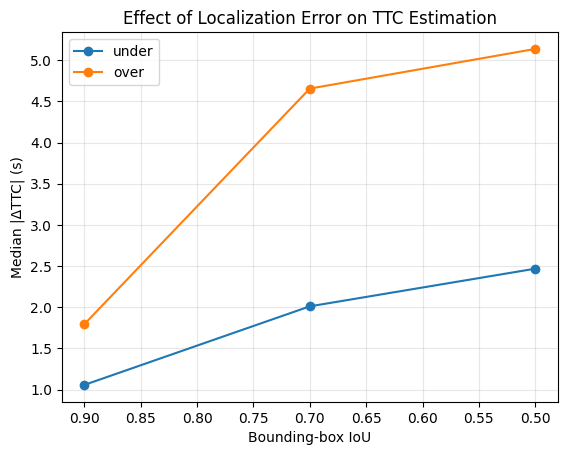

In [31]:
import matplotlib.pyplot as plt
# Localization severity → TTC deviation
# 讓 IoU 按 0.9 → 0.7 → 0.5 排列
plot_df = summary.copy()

for direction in ["under", "over"]:

    temp = (
        plot_df[plot_df["direction"] == direction]
        .sort_values("iou", ascending=False)
    )

    plt.plot(
        temp["iou"],
        temp["median_delta"],
        marker="o",
        label=direction
    )

plt.gca().invert_xaxis()

plt.xlabel("Bounding-box IoU")
plt.ylabel("Median |ΔTTC| (s)")
plt.title("Effect of Localization Error on TTC Estimation")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

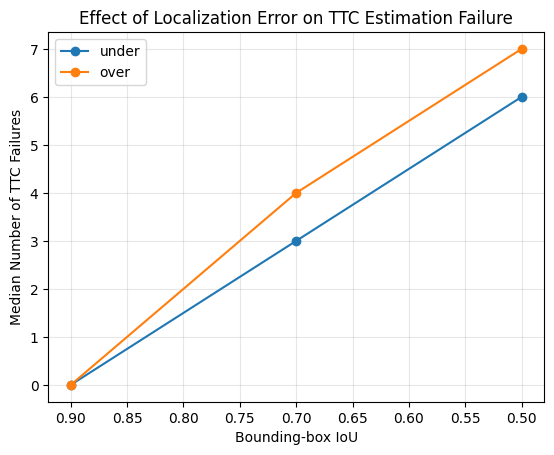

In [32]:
#TTC estimation failure
for direction in ["under", "over"]:

    temp = (
        summary[summary["direction"] == direction]
        .sort_values("iou", ascending=False)
    )

    plt.plot(
        temp["iou"],
        temp["median_failures"],
        marker="o",
        label=direction
    )

plt.gca().invert_xaxis()

plt.xlabel("Bounding-box IoU")
plt.ylabel("Median Number of TTC Failures")
plt.title("Effect of Localization Error on TTC Estimation Failure")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

所以目前兩張圖共同支持：
As localization error severity increased, TTC estimation became less stable, resulting in both larger TTC deviations and more estimation failures.

failure：
A TTC estimation failure was defined as a frame where the baseline TTC was valid, but the perturbed TTC became unavailable because the estimated scale expansion rate was non-positive (\(\dot{s}\le0\)).

(不是程式壞掉或漏檢測，而是 localization perturbation 改變了 temporal scale trajectory，導致 TTC estimator無法產生>0的TTC)